In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

In [133]:

dtype_settings = {'BIN': str, 'BBL': str, 'Address ZIP': str, 'JURISDICTION NAME': str}

df_demo = pd.read_csv("/Users/santiago/Desktop/Python projects/Prueba/Demographic_Statistics_By_Zip_Code.csv", dtype={'JURISDICTION NAME': str})
df_biz = pd.read_csv("/Users/santiago/Desktop/Python projects/Prueba/Legally_Operating_Businesses.csv", dtype=dtype_settings, low_memory=False)

print("Datasets importados sin errores de tipo.")

Datasets importados sin errores de tipo.


In [ ]:

def to_snake_case(name):
    # Reemplazar espacios y caracteres especiales por guiones bajos y pasa a minúsculas
    s1 = re.sub(r'[^a-zA-Z0-9]', '_', name)
    return re.sub(r'_+', '_', s1).lower().strip('_')

# Aplicar a ambos DataFrames
df_biz.columns = [to_snake_case(col) for col in df_biz.columns]
df_demo.columns = [to_snake_case(col) for col in df_demo.columns]

# Estandarizar el nombre de la llave de unión
df_demo = df_demo.rename(columns={'jurisdiction_name': 'zip_key'})
df_biz = df_biz.rename(columns={'address_zip': 'zip_key'})

# Asegurar que el ZIP sea string y no tenga espacios
df_demo['zip_key'] = df_demo['zip_key'].astype(str).str.strip()
df_biz['zip_key'] = df_biz['zip_key'].astype(str).str.strip()
# Tomar solo los primeros 5 caracteres para asegurar coincidencia
df_biz['zip_key'] = df_biz['zip_key'].str[:5]

# Test
print("Columnas Negocios:", df_biz.columns.tolist()[:5])
print("Columnas Demografía:", df_demo.columns.tolist()[:5])

Columnas Negocios: ['dca_license_number', 'license_type', 'license_expiration_date', 'license_status', 'license_creation_date']
Columnas Demografía: ['zip_key', 'count_participants', 'count_female', 'percent_female', 'count_male']


In [ ]:
# --- PARTE 2: Limpieza de Negocios ---

# 1. Ver nulos 
print("--- NULOS EN NEGOCIOS (df_biz) ---")
print(df_biz.isnull().sum())

print("\n" + "="*30 + "\n")

# 2. Eliminar registros sin ZIP (llave), sin Tipo de Licencia ni Industria

df_biz_clean = df_biz.dropna(subset=['zip_key', 'license_type', 'industry']).copy()

# 3. Asegurar formato de 5 dígitos 'zip_key'
df_biz_clean['zip_key'] = df_biz_clean['zip_key'].astype(str).str.strip().str[:5]

print(f"Limpieza exitosa. Quedan {len(df_biz_clean)} registros.")

--- NULOS EN NEGOCIOS (df_biz) ---
dca_license_number                    0
license_type                          0
license_expiration_date           16591
license_status                        0
license_creation_date                 0
industry                              0
business_name                        56
business_name_2                  218651
address_building                  91954
address_street_name               90921
secondary_address_street_name    265253
address_city                        796
address_state                       990
zip_key                             843
contact_phone_number              10220
address_borough                   92455
borough_code                     105596
community_board                  110170
council_district                 109698
bin                              111665
bbl                              111663
nta                              122990
census_tract                     122990
detail                           229478
longi

In [ ]:
# --- PARTE 3: Limpieza Demográfica ---

# 1. Ver nulos 
print("--- NULOS EN DEMOGRAFÍA (df_demo) ---")
print(df_demo.isnull().sum())

print("\n" + "="*30 + "\n")

# 2. Limpieza crítica: Filtrar solo ZIPs con población real (> 0)

df_demo_clean = df_demo[df_demo['count_participants'] > 0].copy()

# 3. Asegurar que el ZIP sea string y de 5 dígitos 'zip_key')
df_demo_clean['zip_key'] = df_demo_clean['zip_key'].astype(str).str.strip().str[:5]

print(f"Limpieza demográfica exitosa. Quedan {len(df_demo_clean)} zonas postales.")

--- NULOS EN DEMOGRAFÍA (df_demo) ---
zip_key                                0
count_participants                     0
count_female                           0
percent_female                         0
count_male                             0
percent_male                           0
count_gender_unknown                   0
percent_gender_unknown                 0
count_gender_total                     0
percent_gender_total                   0
count_pacific_islander                 0
percent_pacific_islander               0
count_hispanic_latino                  0
percent_hispanic_latino                0
count_american_indian                  0
percent_american_indian                0
count_asian_non_hispanic               0
percent_asian_non_hispanic             0
count_white_non_hispanic               0
percent_white_non_hispanic             0
count_black_non_hispanic               0
percent_black_non_hispanic             0
count_other_ethnicity                  0
percent_other_ethni

In [ ]:
# --- PARTE 4: Limpieza y Filtrado Final ---

# 1. Eliminar filas donde no haya ZIP o Industria (usando nombres snake_case)
# Nota: 'zip_key' es a 'address_zip' en la Parte 1
df_biz_clean = df_biz.dropna(subset=['zip_key', 'industry']).copy()

# 2. Filtrar para quedarnos solo con el estado de NY
# El nombre original 'Address State' ahora es 'address_state'
df_biz_clean = df_biz_clean[df_biz_clean['address_state'] == 'NY']

# 3. Verificación final de nulos
print("Nulos restantes en columnas clave de Negocios:")
print(df_biz_clean[['zip_key', 'industry', 'license_type']].isnull().sum())

print(f"\nRegistros útiles restantes en Negocios: {len(df_biz_clean)}")

# 4. Limpieza final del dataset demográfico
# 'jurisdiction_name' ahora es 'zip_key'
df_demo_clean = df_demo.dropna(subset=['zip_key', 'count_participants']).copy()

# Verificación rápida:
print(f"Registros en demografía después de limpiar: {len(df_demo_clean)}")

Nulos restantes en columnas clave de Negocios:
zip_key         0
industry        0
license_type    0
dtype: int64

Registros útiles restantes en Negocios: 253708
Registros en demografía después de limpiar: 236


In [ ]:
# --- PARTE 5: Normalización de Tipos de Datos ---

# --- DATASET DEMO ---
# 1. El ZIP a String 
df_demo_clean['zip_key'] = df_demo_clean['zip_key'].astype(str).str.strip()

# 2. Porcentajes (float) y conteos (int)

cols_pct = [col for col in df_demo_clean.columns if 'percent' in col]
cols_cnt = [col for col in df_demo_clean.columns if 'count' in col]
df_demo_clean[cols_pct] = df_demo_clean[cols_pct].astype(float)
df_demo_clean[cols_cnt] = df_demo_clean[cols_cnt].astype(int)

# --- DATASET BIZ ---
# 1. El ZIP a String (usando 'zip_key' y quitando el .0)
df_biz_clean['zip_key'] = df_biz_clean['zip_key'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

# 2. Categorías a String 
cols_cat = ['industry', 'license_type', 'address_state']
df_biz_clean[cols_cat] = df_biz_clean[cols_cat].astype(str)

print("Conversión de tipos completada exitosamente.")

Conversión de tipos completada exitosamente.


In [ ]:
# --- PARTE 6: Formateo Exacto de ZIP Codes ---

# Normalizar el ZIP a 5 dígitos exactos 
def format_zip(z):
    return str(z).split('.')[0].zfill(5)[:5]

# Columna UNIFICADA 'zip_key' en ambos DataFrames
df_biz_clean['zip_key'] = df_biz_clean['zip_key'].apply(format_zip)
df_demo_clean['zip_key'] = df_demo_clean['zip_key'].apply(format_zip)

# Verificación de coincidencia 
zip_biz = set(df_biz_clean['zip_key'])
zip_demo = set(df_demo_clean['zip_key'])
coincidencias = zip_biz.intersection(zip_demo)

print(f"ZIPs en negocios: {len(zip_biz)}")
print(f"ZIPs en demografía: {len(zip_demo)}")
print(f"--- RESULTADO CRÍTICO ---")
print(f"¡Tenemos {len(coincidencias)} códigos postales en común para analizar!")

if len(coincidencias) == 0:
    print("ADVERTENCIA: No hay coincidencias. Revisa el formato de los datos.")

ZIPs en negocios: 977
ZIPs en demografía: 236
--- RESULTADO CRÍTICO ---
¡Tenemos 222 códigos postales en común para analizar!


In [ ]:
# --- PARTE 7: Unión y Cálculo de Densidad ---

# 1. Agrupamiento de licencias tipo 'Business'

biz_grouped = (df_biz_clean[df_biz_clean['license_type'].str.strip().str.lower() == 'business']
               .groupby('zip_key')
               .size()
               .reset_index(name='total_biz_licenses'))

# 2. Unión (Merge)
df_final = pd.merge(df_demo_clean, biz_grouped, on='zip_key', how='inner')

# 3. Filtro de representatividad (> 100 participantes)

df_final = df_final[df_final['count_participants'] > 100].copy()

# 4. Cálculo de métrica de densidad
df_final['biz_density'] = df_final['total_biz_licenses'] / df_final['count_participants']

print(f"Dataset final listo con {len(df_final)} registros.")
print(f"Densidad promedio de negocios: {df_final['biz_density'].mean():.4f}")

Dataset final listo con 11 registros.
Densidad promedio de negocios: 5.4891


**Pregunta 1 - concentraciòn de negocios por perfil demografico**

In [ ]:
# --- PARTE 8: Distribución Estimada de Licencias ---

# 1. Atribución de licencias por grupo demográfico

df_final['asian_licenses'] = (df_final['total_biz_licenses'] * df_final['percent_asian_non_hispanic']).round()
df_final['white_licenses'] = (df_final['total_biz_licenses'] * df_final['percent_white_non_hispanic']).round()
df_final['black_licenses'] = (df_final['total_biz_licenses'] * df_final['percent_black_non_hispanic']).round()
df_final['hispanic_licenses'] = (df_final['total_biz_licenses'] * df_final['percent_hispanic_latino']).round()

# 2. Selección de columnas para el reporte (usando los nuevos nombres)
cols_reporte = [
    'zip_key', 'total_biz_licenses', 'asian_licenses', 
    'white_licenses', 'black_licenses', 'hispanic_licenses'
]

# 3. Mostrar los 10 ZIP Codes con más licencias
print("--- DISTRIBUCIÓN DE LICENCIAS POR DEMOGRAFÍA Y ZIP CODE ---")
print(df_final[cols_reporte].sort_values(by='total_biz_licenses', ascending=False).head(10))

# 4. Total estimado en la muestra
print("\n--- TOTAL ESTIMADO DE LICENCIAS EN LA MUESTRA POR GRUPO ---")
resumen_grupos = df_final[['asian_licenses', 'white_licenses', 'black_licenses', 'hispanic_licenses']].sum()
print(resumen_grupos)

--- DISTRIBUCIÓN DE LICENCIAS POR DEMOGRAFÍA Y ZIP CODE ---
    zip_key  total_biz_licenses  asian_licenses  white_licenses  \
120   11223                1795           108.0          1562.0   
115   11218                1761            53.0          1514.0   
72    10467                1651            66.0            17.0   
126   11230                1476            44.0          1284.0   
116   11219                1381             0.0          1326.0   
201   12428                   3             0.0             3.0   
207   12754                   3             0.0             3.0   
205   12734                   2             0.0             2.0   
208   12779                   1             0.0             1.0   
209   12783                   1             0.0             1.0   

     black_licenses  hispanic_licenses  
120            18.0               18.0  
115            88.0               18.0  
72            726.0              792.0  
126            15.0                0.0

In [ ]:
# --- PARTE 9: Consolidación y Perfilado (Versión Optimizada) ---

# 1. Obtener Industria Líder por ZIP en un solo paso
top_industries = (df_biz_clean[df_biz_clean['license_type'].str.lower() == 'business']
                  .groupby(['zip_key', 'industry']).size()
                  .reset_index(name='n')
                  .sort_values(['zip_key', 'n'], ascending=[True, False])
                  .drop_duplicates('zip_key'))

# 2. Enriquecer df_final: Etnia Predominante + Industria

df_final = df_final.assign(
    etnia_raw = df_final[vars_demo].idxmax(axis=1),
    porcentaje_etnia = df_final[vars_demo].max(axis=1),
    etnia_predominante = lambda x: x['etnia_raw'].str.replace('percent_', '').str.replace('_non_hispanic', '').str.title()
).merge(top_industries[['zip_key', 'industry']], on='zip_key', how='left').rename(columns={'industry': 'industria_lider'})

# 3. Reporte Ejecutivo Compacto
print("--- RESUMEN ESTRATÉGICO POR PERFIL DEMOGRÁFICO ---")
reporte = (df_final.groupby('etnia_predominante')
           .agg(densidad_media=('biz_density', 'mean'),
                industria_top=('industria_lider', lambda x: x.mode()[0] if not x.empty else "N/A"))
           .sort_values('densidad_media', ascending=False))

print(reporte)

--- RESUMEN ESTRATÉGICO POR PERFIL DEMOGRÁFICO ---
                    densidad_media                industria_top
etnia_predominante                                             
Hispanic_Latino          15.575472        Tobacco Retail Dealer
White                     4.480494  Home Improvement Contractor


In [ ]:
# --- PARTE 10: Cálculo de Correlación Específica ---

# 1. Definir las columnas demográficas que queremos contrastar
vars_demo = [
    'percent_white_non_hispanic', 
    'percent_black_non_hispanic', 
    'percent_hispanic_latino', 
    'percent_asian_non_hispanic'
]

# 2. Calculo de la correlación de Pearson específicamente contra 'biz_density'

analisis_correlacion = df_final[vars_demo + ['biz_density']].corr()['biz_density'].sort_values(ascending=False)

# 3. Eliminar la autocorrelación 
resultado_q1 = analisis_correlacion.drop('biz_density')

print("--- RESULTADO PREGUNTA 1: CORRELACIÓN DE DENSIDAD ---")
print(resultado_q1)

# 4. Interpretación rápida
max_corr = resultado_q1.index[0]
val_corr = resultado_q1.values[0]

print(f"\nInterpretación: El grupo con mayor impacto es {max_corr} con un coeficiente de {val_corr:.2f}")

--- RESULTADO PREGUNTA 1: CORRELACIÓN DE DENSIDAD ---
percent_asian_non_hispanic    0.897708
percent_black_non_hispanic    0.539837
percent_hispanic_latino       0.486070
percent_white_non_hispanic   -0.580697
Name: biz_density, dtype: float64

Interpretación: El grupo con mayor impacto es percent_asian_non_hispanic con un coeficiente de 0.90


/var/folders/w6/w06s4ql12rj40xcmyrsjrmcw0000gn/T/ipykernel_26714/2070134804.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlaciones.values, y=correlaciones.index, ax=axes[0], palette="viridis")
/var/folders/w6/w06s4ql12rj40xcmyrsjrmcw0000gn/T/ipykernel_26714/2070134804.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=resumen_final.index, y='biz_density', data=resumen_final, ax=axes[1], palette="magma")


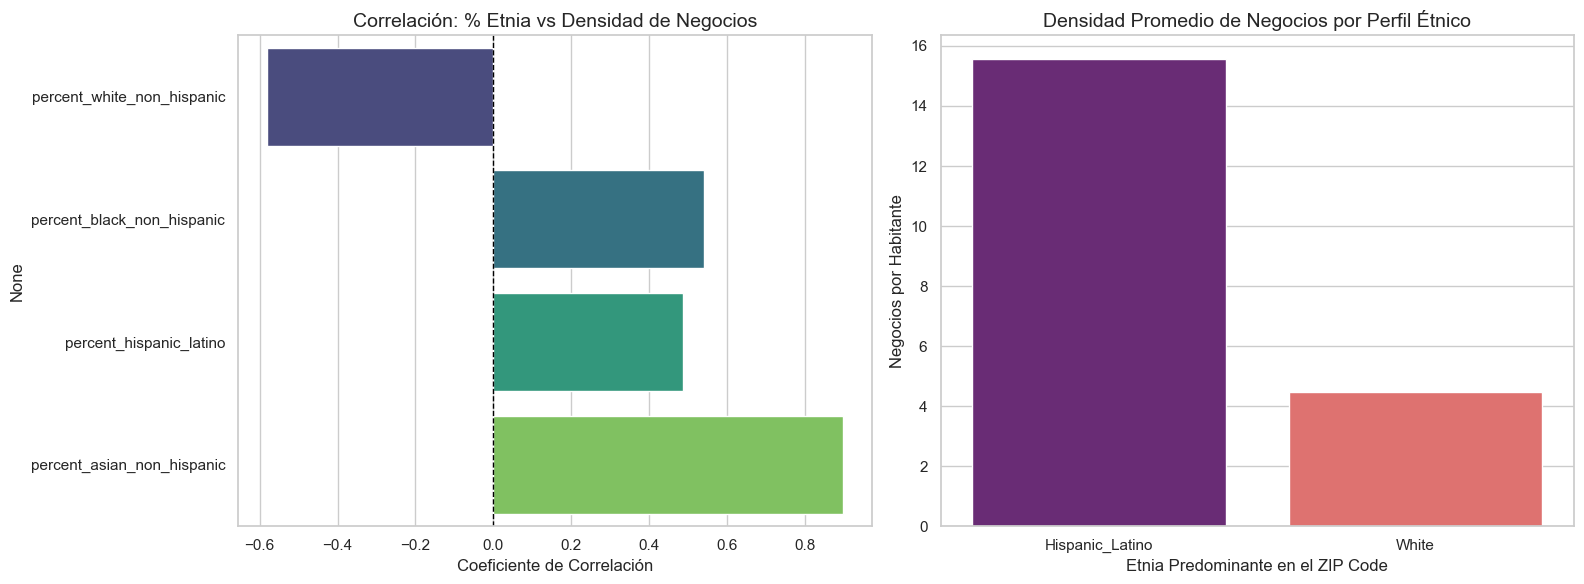

In [ ]:

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GRAFICO 1: Barras de Correlación

sns.barplot(x=correlaciones.values, y=correlaciones.index, ax=axes[0], palette="viridis")
axes[0].set_title('Correlación: % Etnia vs Densidad de Negocios', fontsize=14)
axes[0].set_xlabel('Coeficiente de Correlación')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)

# GRAFICO 2: Promedio de Densidad por Categoría


sns.barplot(x=resumen_final.index, y='biz_density', data=resumen_final, ax=axes[1], palette="magma")
axes[1].set_title('Densidad Promedio de Negocios por Perfil Étnico', fontsize=14)
axes[1].set_ylabel('Negocios por Habitante')
axes[1].set_xlabel('Etnia Predominante en el ZIP Code')

plt.tight_layout()
plt.show()

**Pregunta 2 - concentración de individuos por perfil demografico**

In [ ]:
# --- PREGUNTA 2: Análisis de Licencias Individuales ---

# 1. Agrupamiento con filtro robusto (lower)
indiv_grouped = (df_biz_clean[df_biz_clean['license_type'].str.lower() == 'individual']
               .groupby('zip_key')
               .size()
               .reset_index(name='total_indiv_licenses'))

# 2. Creación del dataset específico para Individuos

df_final_indiv = pd.merge(df_demo_clean, indiv_grouped, on='zip_key', how='inner')

# 3. Filtro de representatividad (Mantenemos > 100 para consistencia)
df_final_indiv = df_final_indiv[df_final_indiv['count_participants'] > 100].copy()

# 4. Cálculo de Densidad de Individuos
df_final_indiv['indiv_density'] = df_final_indiv['total_indiv_licenses'] / df_final_indiv['count_participants']

# 5. Cálculo de Correlación

vars_demo = [
    'percent_white_non_hispanic', 
    'percent_black_non_hispanic', 
    'percent_hispanic_latino', 
    'percent_asian_non_hispanic'
]

correlacion_indiv = df_final_indiv[vars_demo + ['indiv_density']].corr()['indiv_density'].drop('indiv_density').sort_values(ascending=False)

print("--- RESULTADO PREGUNTA 2: CORRELACIÓN INDIVIDUOS ---")
print(correlacion_indiv)

--- RESULTADO PREGUNTA 2: CORRELACIÓN INDIVIDUOS ---
percent_asian_non_hispanic    0.895020
percent_black_non_hispanic    0.469637
percent_hispanic_latino       0.405680
percent_white_non_hispanic   -0.513417
Name: indiv_density, dtype: float64


In [ ]:
# --- PARTE 2 PREGUNTA 2: Distribución Proporcional de Individuos ---

# 1. Atribución de licencias individuales por grupo (basado en el ZIP)

df_final_indiv['asian_indiv'] = (df_final_indiv['total_indiv_licenses'] * df_final_indiv['percent_asian_non_hispanic']).round()
df_final_indiv['white_indiv'] = (df_final_indiv['total_indiv_licenses'] * df_final_indiv['percent_white_non_hispanic']).round()
df_final_indiv['black_indiv'] = (df_final_indiv['total_indiv_licenses'] * df_final_indiv['percent_black_non_hispanic']).round()
df_final_indiv['hispanic_indiv'] = (df_final_indiv['total_indiv_licenses'] * df_final_indiv['percent_hispanic_latino']).round()

# 2. Selección de columnas 
cols_indiv_reporte = [
    'zip_key', 'total_indiv_licenses', 'asian_indiv', 
    'white_indiv', 'black_indiv', 'hispanic_indiv'
]

# 3. Mostrar los 10 ZIP Codes líderes en licencias individuales
print("--- TOP 10 ZIP CODES: LICENCIAS INDIVIDUALES ---")
top_10_indiv = df_final_indiv[cols_indiv_reporte].sort_values(by='total_indiv_licenses', ascending=False).head(10)
print(top_10_indiv)

# 4. Total acumulado en la muestra (Voz del dato final)
print("\n--- IMPACTO ESTIMADO TOTAL POR GRUPO (INDIVIDUOS) ---")
totales_indiv = df_final_indiv[['asian_indiv', 'white_indiv', 'black_indiv', 'hispanic_indiv']].sum()
print(totales_indiv)

--- TOP 10 ZIP CODES: LICENCIAS INDIVIDUALES ---
    zip_key  total_indiv_licenses  asian_indiv  white_indiv  black_indiv  \
123   11230                   905         27.0        787.0          9.0   
112   11218                   890         27.0        765.0         44.0   
117   11223                   765         46.0        666.0          8.0   
70    10467                   662         26.0          7.0        291.0   
113   11219                   519          0.0        498.0          0.0   
203   12754                     8          0.0          8.0          0.0   
194   12428                     5          0.0          5.0          0.0   
208   12783                     5          0.0          5.0          0.0   
200   12734                     3          0.0          3.0          0.0   
207   12779                     3          0.0          3.0          0.0   

     hispanic_indiv  
123             0.0  
112             9.0  
117             8.0  
70            318.0  
113 

In [ ]:
# --- PARTE 3 PREGUNTA 2: Industrias Top (Individuos) ---

# 1. Industria líder por ZIP para licencias Individuales

top_indiv_industries = (df_biz_clean[df_biz_clean['license_type'].str.lower() == 'individual']
                        .groupby(['zip_key', 'industry']).size()
                        .reset_index(name='n')
                        .sort_values(['zip_key', 'n'], ascending=[True, False])
                        .drop_duplicates('zip_key'))

# 2. dataframe de individuos con la etnia y la industria

df_final_indiv = df_final_indiv.assign(
    etnia_predominante = df_final_indiv[vars_demo].idxmax(axis=1).str.replace('percent_', '').str.replace('_non_hispanic', '').str.title(),
    porcentaje_etnia = df_final_indiv[vars_demo].max(axis=1)
).merge(top_indiv_industries[['zip_key', 'industry']], on='zip_key', how='left').rename(columns={'industry': 'industria_lider'})

# --- REPORTES RÁPIDOS ---

print("1. CORRELACIÓN (INDIVIDUOS):")
print(df_final_indiv[vars_demo + ['indiv_density']].corr()['indiv_density'].sort_values(ascending=False))

print("\n2. TOP 5 ZIP CODES (MAYOR DENSIDAD INDIVIDUOS):")
print(df_final_indiv[['zip_key', 'etnia_predominante', 'indiv_density', 'industria_lider']]
      .sort_values('indiv_density', ascending=False).head(5))

print("\n3. RESUMEN POR GRUPO (INDIVIDUOS):")
# Agrupar para ver qué industria domina en cada perfil demográfico
resumen_indiv = (df_final_indiv.groupby('etnia_predominante')
                 .agg(densidad_media=('indiv_density', 'mean'),
                      industria_top=('industria_lider', lambda x: x.mode()[0] if not x.empty else "N/A"))
                 .sort_values('densidad_media', ascending=False))
print(resumen_indiv)

1. CORRELACIÓN (INDIVIDUOS):
indiv_density                 1.000000
percent_asian_non_hispanic    0.895020
percent_black_non_hispanic    0.469637
percent_hispanic_latino       0.405680
percent_white_non_hispanic   -0.513417
Name: indiv_density, dtype: float64

2. TOP 5 ZIP CODES (MAYOR DENSIDAD INDIVIDUOS):
  zip_key etnia_predominante  indiv_density               industria_lider
1   11218              White       8.018018  Home Improvement Salesperson
3   11223              White       7.018349  Home Improvement Salesperson
0   10467    Hispanic_Latino       6.245283  Home Improvement Salesperson
4   11230              White       3.649194  Home Improvement Salesperson
2   11219              White       2.425234  Home Improvement Salesperson

3. RESUMEN POR GRUPO (INDIVIDUOS):
                    densidad_media                 industria_top
etnia_predominante                                              
Hispanic_Latino           6.245283  Home Improvement Salesperson
White           

/var/folders/w6/w06s4ql12rj40xcmyrsjrmcw0000gn/T/ipykernel_26714/1364320142.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlaciones_indiv.values, y=correlaciones_indiv.index, ax=axes[0], palette="viridis")
/var/folders/w6/w06s4ql12rj40xcmyrsjrmcw0000gn/T/ipykernel_26714/1364320142.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=resumen_indiv_final.index, y='indiv_density', data=resumen_indiv_final, ax=axes[1], palette="magma")


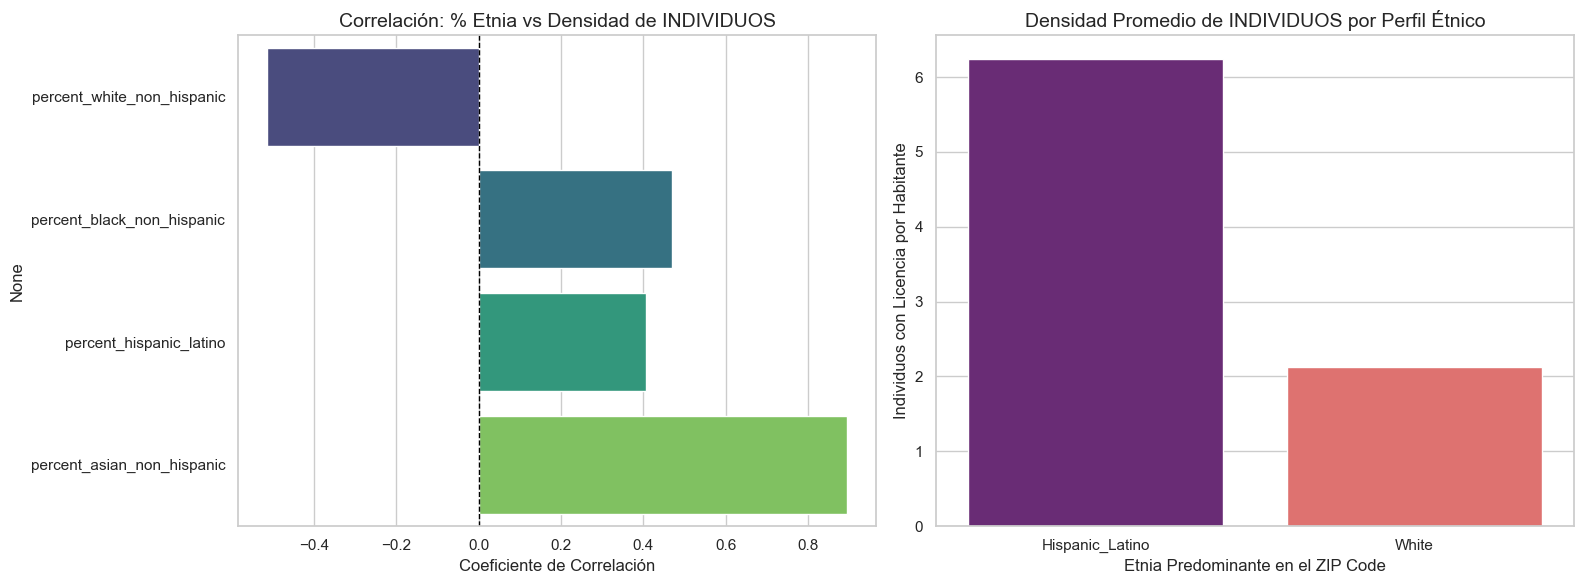

In [ ]:
# Configuración de estilo
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# GRAFICO 1: Barras de Correlación (Individuos)

sns.barplot(x=correlaciones_indiv.values, y=correlaciones_indiv.index, ax=axes[0], palette="viridis")
axes[0].set_title('Correlación: % Etnia vs Densidad de INDIVIDUOS', fontsize=14)
axes[0].set_xlabel('Coeficiente de Correlación')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)

# GRAFICO 2: Promedio de Densidad por Categoría (Individuos)

sns.barplot(x=resumen_indiv_final.index, y='indiv_density', data=resumen_indiv_final, ax=axes[1], palette="magma")
axes[1].set_title('Densidad Promedio de INDIVIDUOS por Perfil Étnico', fontsize=14)
axes[1].set_ylabel('Individuos con Licencia por Habitante')
axes[1].set_xlabel('Etnia Predominante en el ZIP Code')

plt.tight_layout()
plt.show()

In [ ]:
# --- PREGUNTA 3: Regresión Lineal y Evaluación de Predictores ---


# Definición de variables y set de entrenamiento
vars_demo = ['percent_white_non_hispanic', 'percent_black_non_hispanic', 
             'percent_hispanic_latino', 'percent_asian_non_hispanic']

# Asegurar subset para el modelo
df_model = df_final.copy()
X, y = df_model[vars_demo], df_model['biz_density']

# Ajuste del modelo
reg = LinearRegression().fit(X, y)
df_model['pred'] = reg.predict(X)

# Métricas de performance
r2 = r2_score(y, df_model['pred'])
mae = mean_absolute_error(y, df_model['pred'])

print(f"--- MÉTRICAS DEL MODELO ---")
print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:.4f}")

# Coeficientes: Peso de cada grupo demográfico en la densidad
importancia = pd.Series(reg.coef_, index=vars_demo).sort_values(ascending=False)
print("\n--- IMPACTO POR VARIABLE (COEFICIENTES) ---")
print(importancia)

# Comparativa rápida: Real vs Predicción
print("\n--- VALIDACIÓN DE PREDICCIONES (TOP 5) ---")
print(df_model[['zip_key', 'biz_density', 'pred']].sort_values('biz_density', ascending=False).head(5))

--- MÉTRICAS DEL MODELO ---
R2 Score: 0.9110
MAE: 1.4491

--- IMPACTO POR VARIABLE (COEFICIENTES) ---
percent_asian_non_hispanic    295.229972
percent_black_non_hispanic    216.736385
percent_white_non_hispanic     44.131150
percent_hispanic_latino      -105.302623
dtype: float64

--- VALIDACIÓN DE PREDICCIONES (TOP 5) ---
  zip_key  biz_density       pred
3   11223    16.467890  15.779278
1   11218    15.864865  15.150523
0   10467    15.575472  15.626302
2   11219     6.453271   0.922946
4   11230     5.951613   7.975405


/var/folders/w6/w06s4ql12rj40xcmyrsjrmcw0000gn/T/ipykernel_26714/2148311108.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancia.values, y=importancia.index, ax=ax1, palette='viridis')


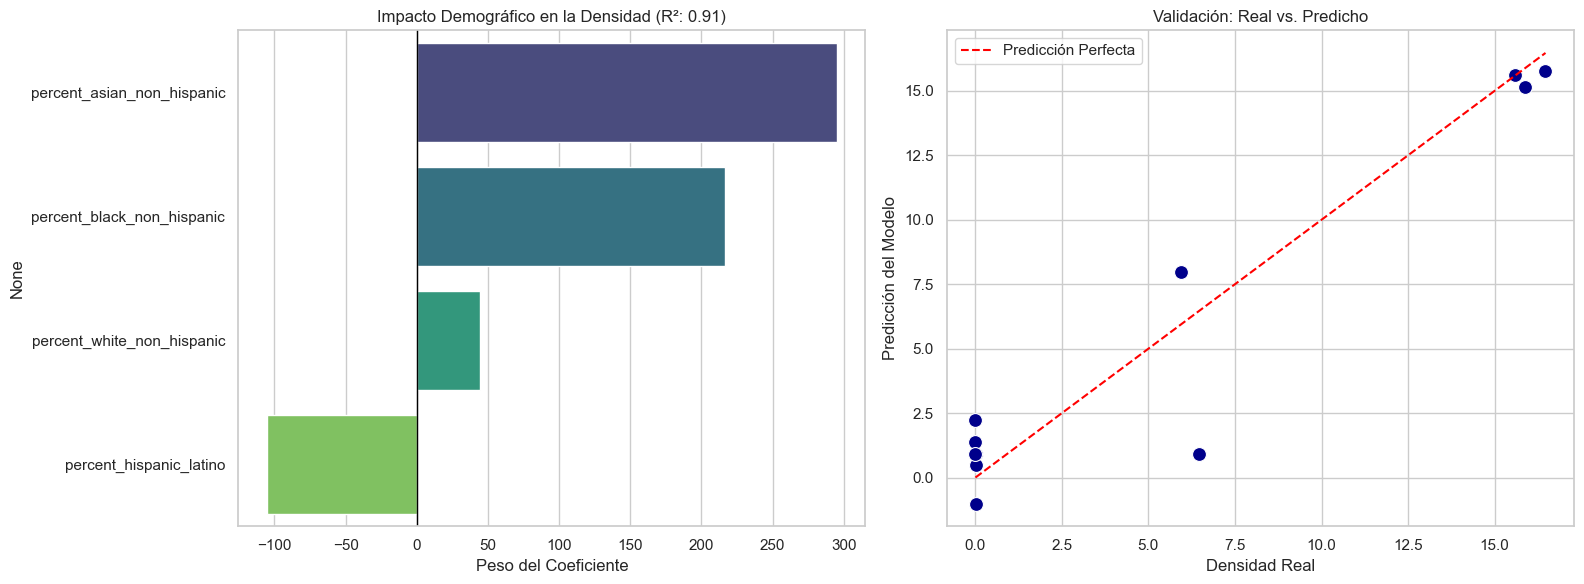

In [ ]:
# --- VISUALIZACIÓN FINAL: Importancia y Validación ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico de Importancia (Coeficientes)
sns.barplot(x=importancia.values, y=importancia.index, ax=ax1, palette='viridis')
ax1.set_title(f'Impacto Demográfico en la Densidad (R²: {r2:.2f})')
ax1.set_xlabel('Peso del Coeficiente')
ax1.axvline(0, color='black', lw=1)

# 2. Gráfico de Validación (Real vs Predicción)
sns.scatterplot(x=df_model['biz_density'], y=df_model['pred'], ax=ax2, s=100, color='darkblue')
line_coords = [df_model['biz_density'].min(), df_model['biz_density'].max()]
ax2.plot(line_coords, line_coords, '--', color='red', label='Predicción Perfecta')
ax2.set_title('Validación: Real vs. Predicho')
ax2.set_xlabel('Densidad Real')
ax2.set_ylabel('Predicción del Modelo')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- EXPORTACIÓN DE RESULTADOS ---

# 1. Exportar el dataset de Negocios 
df_model.to_csv('nyc_business_analysis_final.csv', index=False)

# 2. Exportar el dataset de Individuos
df_final_indiv.to_csv('nyc_individual_analysis_final.csv', index=False)

# 3. Exportar el dataset final

df_final.to_csv('nyc_final_analysis.csv', index=False)

print("¡Archivos exportados con éxito!")
print("1. nyc_business_analysis_final.csv")
print("2. nyc_individual_analysis_final.csv")
print("3. nyc_final_analysis.csv")




¡Archivos exportados con éxito!
1. nyc_business_analysis_final.csv
2. nyc_individual_analysis_final.csv
3. nyc_final_analysis.csv
